# 01 — Baseline PPO on LunarLander-v3

Train a standard PPO agent using the environment's built-in reward, evaluate its performance, and log results to SQLite.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from pathlib import Path

from lunarlander.db_logger import ExperimentLogger

# Paths
CHECKPOINT_DIR = Path('../checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)
DB_PATH = Path('../experiments.db')

print('Setup complete.')

Setup complete.


In [2]:
# Hyperparameters
TOTAL_TIMESTEPS = 500_000
N_STEPS = 2048
BATCH_SIZE = 64
N_EPOCHS = 10
LEARNING_RATE = 3e-4
GAMMA = 0.999
GAE_LAMBDA = 0.98
ENT_COEF = 0.01
SEED = 42
N_EVAL_EPISODES = 50

hyperparams = {
    'total_timesteps': TOTAL_TIMESTEPS,
    'n_steps': N_STEPS,
    'batch_size': BATCH_SIZE,
    'n_epochs': N_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'gamma': GAMMA,
    'gae_lambda': GAE_LAMBDA,
    'ent_coef': ENT_COEF,
    'seed': SEED,
}
print('Hyperparameters:', hyperparams)

Hyperparameters: {'total_timesteps': 500000, 'n_steps': 2048, 'batch_size': 64, 'n_epochs': 10, 'learning_rate': 0.0003, 'gamma': 0.999, 'gae_lambda': 0.98, 'ent_coef': 0.01, 'seed': 42}


In [3]:
# Create environment
def make_env():
    env = gym.make('LunarLander-v3')
    env = Monitor(env)
    return env

env = DummyVecEnv([make_env])
print('Env created. Obs shape:', env.observation_space.shape, 'Action space:', env.action_space)

Env created. Obs shape: (8,) Action space: Discrete(4)


In [4]:
# Train PPO
model = PPO(
    'MlpPolicy',
    env,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,
    learning_rate=LEARNING_RATE,
    gamma=GAMMA,
    gae_lambda=GAE_LAMBDA,
    ent_coef=ENT_COEF,
    verbose=1,
    seed=SEED,
)

print(f'Training for {TOTAL_TIMESTEPS:,} timesteps...')
model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True)
print('Training complete!')

Using cuda device


Output()

/home/har5ha/Desktop/LunarLander/.venv/lib/python3.11/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Training for 500,000 timesteps...


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 94.7     |
|    ep_rew_mean     | -153     |
| time/              |          |
|    fps             | 1398     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 339         |
|    ep_rew_mean          | 244         |
| time/                   |             |
|    fps                  | 1062        |
|    iterations           | 242         |
|    time_elapsed         | 466         |
|    total_timesteps      | 495616      |
| train/                  |             |
|    approx_kl            | 0.007199459 |
|    clip_fraction        | 0.0555      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.702      |
|    explained_variance   | 0.992       |
|    learning_rate        | 0.0003      |
|    loss                 | 1.38        |
|    n_updates            | 2410        |
|    policy_gradient_loss | -0.00102    |
|    value_loss           | 7.94        |
-----------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 346          |
|    ep_rew_mean          | 244          |
| time/                   |              |
|    fps                  | 1062         |
|    iterations           | 243          |
|    time_elapsed         | 468          |
|    total_timesteps      | 497664       |
| train/                  |              |
|    approx_kl            | 0.0046539735 |
|    clip_fraction        | 0.0423       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.65        |
|    explained_variance   | 0.971        |
|    learning_rate        | 0.0003       |
|    loss                 | 12           |
|    n_updates            | 2420         |
|    policy_gradient_loss | -0.00287     |
|    value_loss           | 54.9         |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 353          |
|    ep_rew_mean          | 244          |
| time/                   |              |
|    fps                  | 1062         |
|    iterations           | 244          |
|    time_elapsed         | 470          |
|    total_timesteps      | 499712       |
| train/                  |              |
|    approx_kl            | 0.0038547423 |
|    clip_fraction        | 0.0239       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.686       |
|    explained_variance   | 0.988        |
|    learning_rate        | 0.0003       |
|    loss                 | 10.9         |
|    n_updates            | 2430         |
|    policy_gradient_loss | -0.00266     |
|    value_loss           | 28.6         |
------------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 347         |
|    ep_rew_mean          | 246         |
| time/                   |             |
|    fps                  | 1062        |
|    iterations           | 245         |
|    time_elapsed         | 472         |
|    total_timesteps      | 501760      |
| train/                  |             |
|    approx_kl            | 0.008110326 |
|    clip_fraction        | 0.0509      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.703      |
|    explained_variance   | 0.984       |
|    learning_rate        | 0.0003      |
|    loss                 | 2.69        |
|    n_updates            | 2440        |
|    policy_gradient_loss | -0.00537    |
|    value_loss           | 7.67        |
-----------------------------------------


Training complete!


In [5]:
# Evaluate
eval_env = DummyVecEnv([make_env])

mean_reward, std_reward = evaluate_policy(
    model, eval_env, n_eval_episodes=N_EVAL_EPISODES, deterministic=True
)
print(f'Mean reward: {mean_reward:.2f} +/- {std_reward:.2f}')

Mean reward: 270.92 +/- 20.92


In [6]:
# Compute success rate (reward > 200) and crash rate
raw_env = gym.make('LunarLander-v3')
episode_rewards = []
landed_count = 0
crashed_count = 0
ep_lengths = []

for _ in range(N_EVAL_EPISODES):
    obs, _ = raw_env.reset()
    ep_reward = 0.0
    ep_len = 0
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = raw_env.step(action)
        ep_reward += reward
        ep_len += 1
        done = terminated or truncated
        if terminated:
            # Positive landing reward means successful landing
            if reward == 100:
                landed_count += 1
            elif reward == -100:
                crashed_count += 1
    episode_rewards.append(ep_reward)
    ep_lengths.append(ep_len)

success_rate = landed_count / N_EVAL_EPISODES
crash_rate = crashed_count / N_EVAL_EPISODES
mean_ep_len = float(np.mean(ep_lengths))

print(f'Success rate (landed): {success_rate:.2%}')
print(f'Crash rate:            {crash_rate:.2%}')
print(f'Mean episode length:   {mean_ep_len:.1f} steps')
raw_env.close()

Success rate (landed): 100.00%
Crash rate:            0.00%
Mean episode length:   272.2 steps


In [7]:
# Save checkpoint
checkpoint_path = CHECKPOINT_DIR / 'baseline_ppo'
model.save(str(checkpoint_path))
print(f'Checkpoint saved to {checkpoint_path}.zip')

Checkpoint saved to ../checkpoints/baseline_ppo.zip


In [8]:
# Log to SQLite
logger = ExperimentLogger(DB_PATH)
row_id = logger.log(
    name='Baseline PPO — LunarLander-v3',
    exp_type='baseline_ppo',
    mean_reward=float(mean_reward),
    std_reward=float(std_reward),
    success_rate=success_rate,
    crash_rate=crash_rate,
    mean_ep_len=mean_ep_len,
    hyperparams=hyperparams,
    notes=f'Standard SB3 PPO on LunarLander-v3, {TOTAL_TIMESTEPS} timesteps.',
)
print(f'Logged to SQLite, row id={row_id}')

# Verify
rows = logger.fetch_all()
print(f'Total experiments in DB: {len(rows)}')
for r in rows:
    print(f"  [{r['id']}] {r['name']} | mean_reward={r['mean_reward']}")

Logged to SQLite, row id=4
Total experiments in DB: 4
  [4] Baseline PPO — LunarLander-v3 | mean_reward=270.92077969999997
  [3] Bradley-Terry Reward Model | mean_reward=None
  [2] Bradley-Terry Reward Model | mean_reward=None
  [1] Baseline PPO — LunarLander-v3 | mean_reward=274.5949815


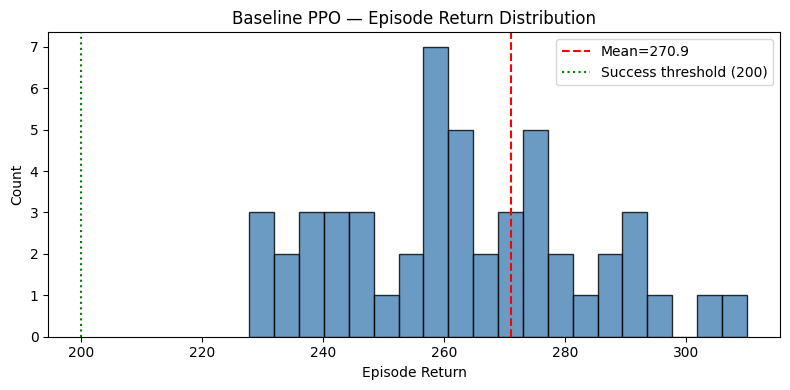

Plot saved.


In [9]:
# Quick reward distribution plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(episode_rewards, bins=20, edgecolor='black', color='steelblue', alpha=0.8)
ax.axvline(mean_reward, color='red', linestyle='--', label=f'Mean={mean_reward:.1f}')
ax.axvline(200, color='green', linestyle=':', label='Success threshold (200)')
ax.set_xlabel('Episode Return')
ax.set_ylabel('Count')
ax.set_title('Baseline PPO — Episode Return Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('../checkpoints/baseline_ppo_rewards.png', dpi=100)
plt.show()
print('Plot saved.')

In [ ]:
# Record baseline agent playing and display as GIF
import imageio
from IPython.display import Image as IPImage, display

render_env = gym.make('LunarLander-v3', render_mode='rgb_array')
frames = []
obs, _ = render_env.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = render_env.step(action)
    frames.append(render_env.render())
    done = terminated or truncated

render_env.close()

gif_path = '../checkpoints/baseline_agent.gif'
imageio.mimsave(gif_path, frames, fps=30)
print(f'Saved {len(frames)} frames → {gif_path}')
display(IPImage(gif_path))